# Simulation CLP PID FF
Import

In [21]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

from package_DBR import *
from Package_Lab import *

Set Graph

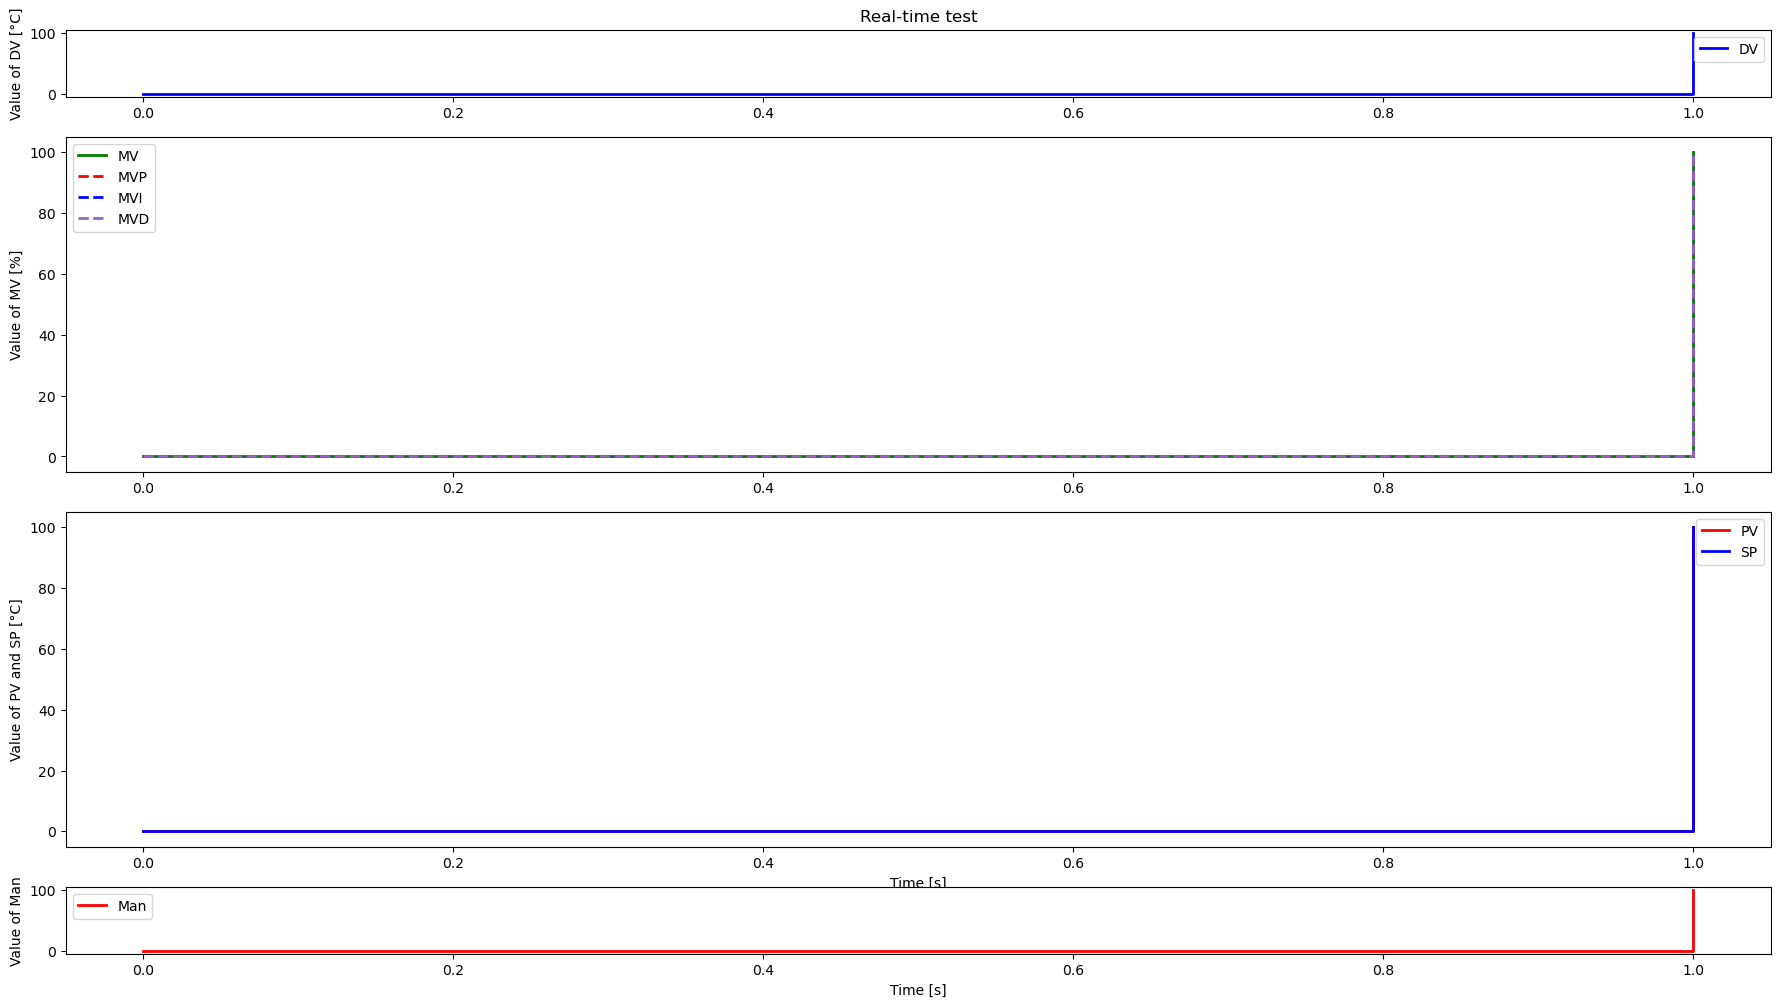

In [22]:
Graph_after = True

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(15,9),
                        gridspec_kw={'height_ratios': [1, 5, 5, 1]})
fig.set_figheight(12)
fig.set_figwidth(22)

l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='DV',where='post')
ax1.set_ylabel('Value of DV [°C]')
ax1.set_title('Real-time test')
ax1.legend(loc='best')

l2, = ax2.step([0,1],[0,100],'g-',linewidth=2,label='MV',where='post')
l6, = ax2.step([0,1],[0,100], color='r', linestyle='--', linewidth=2, label='MVP', where='post')
l7, = ax2.step([0,1],[0,100], color='b', linestyle='--', linewidth=2, label='MVI', where='post')
l8, = ax2.step([0,1],[0,100], color='#9467bd', linestyle='--', linewidth=2, label='MVD', where='post')
ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='best')

l3, = ax3.step([0,1],[0,100],'r-',linewidth=2,label='PV',where='post')
l4, = ax3.step([0,1],[0,100],'b-',linewidth=2,label='SP',where='post')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Value of PV and SP [°C]')
ax3.legend(loc='best') 

l5, = ax4.step([0,1],[0,100],'r-',linewidth=2,label='Man',where='post')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Value of Man')
ax4.legend(loc='best') 

Scenario

In [23]:
Scenario = 4
# 1 - NO FF and Man
# 2 - FF and Man
# 3 - NO FF and NO Man
# 4 - FF and NO Man

Set list

In [24]:
TSim = 1000
Ts = 1
N = int(TSim/Ts) + 1

# Path
if Scenario == 1: # 1 - NO FF and Man
    FF = False
    MVFFPath = {0:0 , TSim: 0}
    SPPath = {0: 77, TSim: 77}
    DVPath = {0: 50, 500:60, TSim: 60}
    ManPath = {0: True, TSim:True}
    MVManPath = {0: 50, TSim: 50}

elif Scenario == 2: # 2 - FF and Man
    FF = True
    SPPath = {0: 77, TSim: 77}
    DVPath = {0: 50, 500:60, TSim: 60}
    ManPath = {0: True, TSim:True}
    MVManPath = {0: 50, TSim: 50}

elif Scenario == 3: # 3 - NO FF and NO Man
    FF = False
    MVFFPath = {0:0 , TSim: 0}
    SPPath = {0: 77, TSim: 77}
    DVPath = {0: 50, 500:60, TSim: 60}
    ManPath = {0: True,225:False, TSim:False}
    MVManPath = {0: 50, 225: 0 , TSim: 0}

elif Scenario == 4: # 4 - FF and NO Man
    FF = True
    SPPath = {0: 77, TSim: 77}
    DVPath = {0: 50, 500:60, TSim: 60}
    ManPath = {0: True,225:False, TSim:False}
    MVManPath = {0: 50, 225: 0 , TSim: 0}

t = []
SP = []

MV = []
MVDelay = []

DV = []
MVFFDelay = []
MVFF_FLL = []
MVFF = []

MVDelayp = []
PV1p = []
PV2p = []

MVDelayd = []
PV1d = []
PV2d = []

MVMan = []
MVP = []
MVI = []
MVD = []
PV = []
PV_P = []
PV_D = []
E = []
Man = []

# Parameters
DV0 = 50
MV0 = 50
PV0 = 77
gamma = 0.9
Kc = 0
Ti = 0
Td = 0
alpha = 0.9
MVMin = 0
MVMax = 100
ManFF = False
Kd = 0.618599605156834
Kp = 0.540610574655048
T1d = 147.5486385332903
T2d = 36.22565494631446
T1p = 130.5026136090156
T2p = 35.46518028608689
Thetap = 14.348568183245677
Thetad = 13.351904889062693

Run simulation

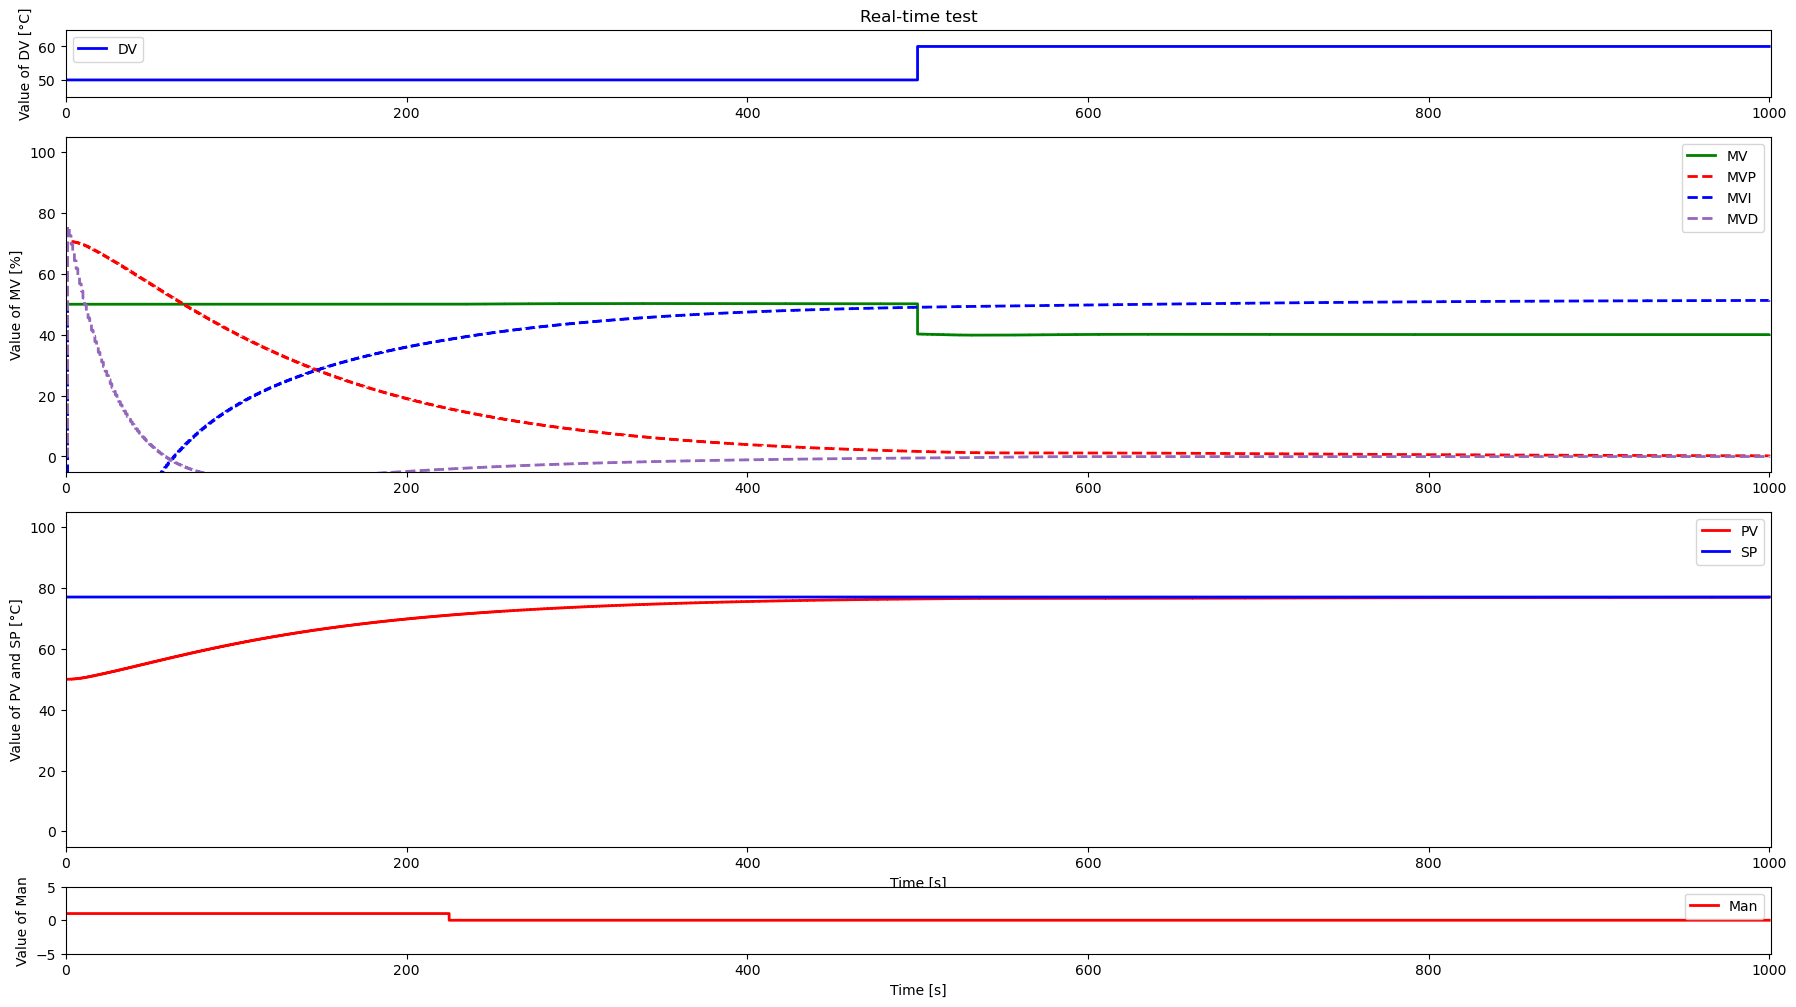

49.9694712672476
-9.92263070455354
2.613831369667254 165.9677938951025 27.88672796587586


In [25]:

for i in range(0,N):

    t.append(i*Ts)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t,MVMan)

    #MVFF
    if FF == True:
        Delay_RT(DV-DV0*np.ones_like(DV),max(0,Thetad-Thetap),Ts,MVFFDelay)
        LL_RT(MVFFDelay,-Kd/Kp,Ts,T1p,T1d,MVFF_FLL)
        LL_RT(MVFF_FLL,1,Ts,T2p,T2d,MVFF,0)
    else:
        SelectPath_RT(MVFFPath,t,MVFF)

    Kc, Ti, Td = IMC_TUNING(Kp,gamma,T1p,T2p)

    PID_RT(SP,PV,Man,MVMan,MVFF,Kc,Ti,Td,alpha,Ts,MVMin,MVMax,MV,MVP,MVI,MVD,E,ManFF,PV0)

    #P(s)
    Delay_RT(MV, Thetap, Ts, MVDelayp,MV0)
    FO_RT(MVDelayp, Kp, T1p, Ts, PV1p, 0)
    FO_RT(PV1p, 1, T2p, Ts, PV2p, 0)

    #D(s)
    Delay_RT(DV - DV0*np.ones_like(DV),Thetad,Ts,MVDelayd,DV0)
    FO_RT(MVDelayd, Kp, T1d, Ts, PV1d, 0)
    FO_RT(PV1d, 1, T2d, Ts, PV2d, 0)

    PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)

    if Graph_after == False:
        print(PV[-1])
        print(MV[-1])
        print(SP[-1])

        l1.set_data(t,DV)
        l2.set_data(t,MV)
        l3.set_data(t,PV)
        l4.set_data(t,SP)
        l5.set_data(t,Man)
        l6.set_data(t,MVP)
        l7.set_data(t,MVI)
        l8.set_data(t,MVD)

        clear_output(wait=True)    

        ax1.set_xlim(0, t[-1]+1)
        ax2.set_xlim(0, t[-1]+1)
        ax3.set_xlim(0, t[-1]+1)
        ax4.set_xlim(0, t[-1]+1)

        if i > 1:
            ax1.set_ylim(myRound(np.min(DV),5)-5, myRound(np.max(DV),5)+5)
            ax2.set_ylim(-5, 105)
            ax3.set_ylim(-5, 105)
            ax4.set_ylim(myRound(np.min(Man),5)-5, myRound(np.max(Man),5)+5) 

        display(fig)  

if Graph_after == True:
    l1.set_data(t,DV)
    l2.set_data(t,MV)
    l3.set_data(t,PV)
    l4.set_data(t,SP)
    l5.set_data(t,Man)
    l6.set_data(t,MVP)
    l7.set_data(t,MVI)
    l8.set_data(t,MVD)

    ax1.set_xlim(0, t[-1]+1)
    ax2.set_xlim(0, t[-1]+1)
    ax3.set_xlim(0, t[-1]+1)
    ax4.set_xlim(0, t[-1]+1)

    ax1.set_ylim(myRound(np.min(DV),5)-5, myRound(np.max(DV),5)+5)
    ax2.set_ylim(-5, 105)
    ax3.set_ylim(-5, 105)
    ax4.set_ylim(myRound(np.min(Man),5)-5, myRound(np.max(Man),5)+5) 

    display(fig) 
    print(PV[0])
    print(MVFF[500])
    print(Kc, Ti, Td)
